In [1]:
from turtledemo.sorting_animate import instructions1

from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
from typing import Dict
import os
import asyncio
import smtplib
from email.message import EmailMessage


In [2]:
load_dotenv(override=True)
model_name = os.getenv("OPENAI_MODEL", "gpt-5-nano")
EMAIL_USERNAME = os.getenv("EMAIL_USERNAME")
EMAIL_PASSWORD = os.getenv("EMAIL_PASSWORD")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_RECIPIENT = os.getenv("EMAIL_RECIPIENT")
EMAIL_SENDER = os.getenv("EMAIL_SENDER")

In [3]:
def send_email(subject: str, text_body: str, html_body: str):
    """Send an email with the given subject and body to the specified recipient."""
    msg = EmailMessage()
    msg['Subject'] = subject
    msg['From'] = EMAIL_SENDER
    msg['To'] = EMAIL_RECIPIENT
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype='html')

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_USERNAME, EMAIL_PASSWORD)
        server.send_message(msg)

In [4]:
send_email("Test Email", "This is a test email sent from the Python script.", "<h1>This is a test email sent from the Python script.</h1>")

In [5]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

In [6]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [7]:
def send_message(subject, text_body, html_body):
    if EMAIL_RECIPIENT:
        send_email(subject, text_body, html_body)
    if pushover_user and pushover_token:
        push(text_body)

In [8]:
send_message("Test Notification", "This is a test notification sent from the Python script.", "<h1>This is a test notification sent from the Python script.</h1>")

Push: This is a test notification sent from the Python script.


In [10]:
intro = """
You are a sales agent working for ComplAI,
a company that provides a SaaS tool for ensuring compliance with the GDPR.
you write emails
"""

instructions1 = intro + " You email style is professional, serious, with gravitas and credibility"
instructions2 = intro + " You email style is witty, snarky, and humorous"
instructions3 = intro + " You email style is concise, to the point, in the style of a busy senior executive"

In [12]:
model_name = os.getenv("OPENAI_MODEL", "gpt-5-nano")
sales_agent1 = Agent(name = "Professional Sales Agent", instructions=instructions1, model=model_name)
sales_agent2 = Agent(name = "Witty Sales Agent", instructions=instructions2, model=model_name)
sales_agent3 = Agent(name = "Concise Sales Agent", instructions=instructions3, model=model_name)

In [13]:
result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Simplify GDPR compliance for [CompanyName] with ComplAI

Hi [FirstName],

I’m [YourName], solutions lead at ComplAI. Many growing teams struggle with GDPR: manual data mapping, time-consuming DPIAs, and slow DSAR responses. ComplAI automates the heavy lifting, so your privacy program is thorough, auditable, and scalable.

How ComplAI helps:
- Automated data inventory and processing activity mapping across systems
- DPIA templates with risk scoring and ready-made reports
- DSAR workflow automation (request intake, verification, fulfillment)
- Vendor risk management and data transfer documentation
- Auditor-ready dashboards and policy templates

Benefits in brief: faster, lower-effort compliance work; clearer evidence for regulators and customers; and reduced risk as you scale.

Could we tailor a 15-minute demo for [CompanyName]? I’m available [Option 1] or [Option 2]. If now isn’t ideal, I can share a brief overview deck instead.

Best regards,
[YourName]
[Title]
ComplAI
[Phone

In [14]:
message = "Write a cold sales email"
with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, input=message),
        Runner.run(sales_agent2, input=message),
        Runner.run(sales_agent3, input=message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")

Subject: Simplify GDPR compliance for [Company]

Hi [FirstName],

I’m [Your Name], Account Executive at ComplAI. GDPR compliance remains time-consuming: data mapping, DSAR handling, DPIAs, and ongoing risk monitoring. ComplAI provides a single platform that automates data inventory and processing activities, streamlines DSAR workflows, automates DPIAs, and delivers an auditable trail for audits—continuously updated as your environment changes.

Benefits include reduced manual effort, faster audit readiness, and clear accountability, with seamless integration into your stack (e.g., Microsoft 365, Google Workspace, Salesforce).

Would you be available for a 15-minute call this week to discuss your GDPR posture and see a quick demo? If so, please share a couple of times or book here: [Calendly link].

Best regards,
[Your Name]
[Title], ComplAI
[Phone]
[Email]
[Website]


Subject: GDPR compliance without the drama (ComplAI)

Hi [FirstName],

I know GDPR isn’t exactly a thrill ride. ComplAI

In [15]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are the most likely to respond to.
Do not give an explanation; reply with the selected email only
"""

sales_picker = Agent(name="Sales Email Picker", instructions=decision, model=model_name)

In [16]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, input=message),
        Runner.run(sales_agent2, input=message),
        Runner.run(sales_agent3, input=message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)
    best = await Runner.run(sales_picker, input=emails)

    print(f"Best sales email:\n{best.final_output}")

Best sales email:
Subject: GDPR compliance without the chaos (yes, really)

Hi [First Name],

If your GDPR program feels like a never-ending game of whack-a-mole—DPIAs here, data maps there, DSARs everywhere—I’ve got good news: ComplAI can automate most of that chaos.

ComplAI is a GDPR compliance SaaS that automates data discovery, DPIAs, DSAR workflows, vendor risk, and audit trails. It gives you a single source of truth, cuts manual work, and helps you sleep at night knowing you’re audit-ready.

What you get:
- Auto data mapping and lineage
- DPIA templates and approvals
- DSAR processing with safeguards
- Vendor risk scoring
- One-click, audit-ready reports

Want to see it in action? A quick 15-minute demo next week, tailored to your stack. I’ll bring the curiosity if you bring the questions.

If you’d rather not hear from me again, reply STOP and I’ll disappear faster than a data breach notice.

Best,
[Name]
Privacy Architect, ComplAI
[Phone] • [Email] • [Website]


In [21]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Sends an email using the provided subject, text body, and HTML body.

    This function takes a subject line, the plain text content, and the HTML
    content of an email and sends it to the recipient(s) as needed. The
    HTML content can be used for rich formatting, while the plain text
    provides a fallback for email clients that do not support rendering HTML.

    :param subject: The subject line of the email.
    :param text_body: The plain text content of the email body.
    :param html_body: The HTML formatted content of the email body.
    :return: A string indicating the result of the email sending process.
    """
    send_email(subject, text_body, html_body)
    return "Email sent successfully."

In [22]:
description = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are the most likely to respond to.
The use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")
sales_sender = Agent(name="Sales Email Sender", instructions=description, model=model_name, model_settings=require_tool, tools=[send_email_tool])

In [23]:
message = "Write a cold sales email"
with trace("Sales email sender workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, input=message),
        Runner.run(sales_agent2, input=message),
        Runner.run(sales_agent3, input=message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Sales email sent: {response.final_output}")

Sales email sent: I chose the first option as the best, because it’s personalized, clear, and includes a concrete 15-minute call CTA along with tangible GDPR benefits.

Email sent
- Subject: A GDPR-compliance solution tailored for [Company]
- Text version (sent):
  Hi [First Name],

  I’m [Your Name] from ComplAI. We help organizations like [Company] meet GDPR requirements with confidence by automating core processes such as data mapping, DPIAs, DSAR handling, records of processing activities, and audit-ready reporting.

  Key benefits of ComplAI:
  - Reduce manual effort and avoid overworked teams
  - Accelerate DPIAs and DSAR responses
  - Maintain demonstrable, audit-ready GDPR compliance

  If you’re open to it, I’d welcome 15 minutes to discuss how we could fit [Company]’s data landscape and regulatory goals. Are you available this week or next for a brief call?

  Best regards,
  [Your Name]
  [Title]
  ComplAI
  [Phone]
  [Email]
  [Website]

  P.S. If now isn’t ideal, I can sha

In [24]:
description = "use this tool to write a sales email. In the input, just instruct it to write a sales email."
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x768e9d3fda30>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False, custom_data_extractor=None, allowed_callers=None, output_json_schema=None)

In [25]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

In [26]:
tools = [tool1, tool2, tool3, send_email_tool]

In [27]:
tools

[FunctionTool(name='sales_email_writer_1', description='use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x768e9d3ff020>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False, custom_data_extractor=None, allowed_callers=None, output_json_schema=None),
 FunctionTool(name='sales_email_writer_2', description='use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input sch

In [28]:
instruction = """
You are a Sales Manager at ComplAI. your gold is to find the single cold sales email using the sales_writer tools.
"""

tasks = """
Follow these steps

1. Generate Drafts: use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write s sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.

2. Evaluate and select: review the drafts and choose the single best email using your judgement of which one is most effective.

3. Use your tool to send the best email (and only the best email) to the use. only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instruction, model=model_name, tools=tools)


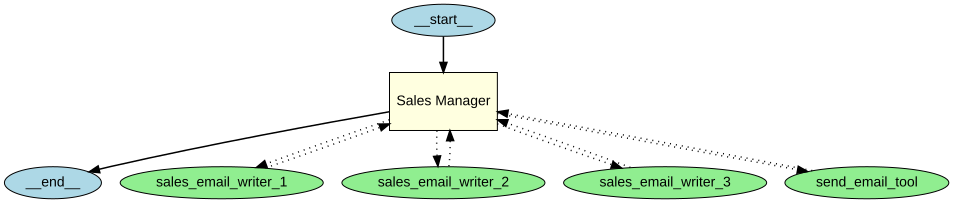

In [30]:
draw_graph(sales_manager)

In [31]:
with trace("Sale managers"):
    result = await Runner.run(sales_manager, tasks)